In [1]:
import os

import cv2

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [28]:


dataset_path = r"archive (22)\chest_xray"




train_path = os.path.join(

    dataset_path,

    "train"

)

test_path = os.path.join(

    dataset_path,

    "test"

)

val_path = os.path.join(

    dataset_path,

    "val"

)

print("\n")

print("="*70)

print("Dataset Path Loaded Successfully")

print("="*70)




Dataset Path Loaded Successfully


In [29]:
classes = os.listdir(

    train_path

)

print("\n")

print("="*70)

print("Classes")

print("="*70)

print(classes)



Classes
['NORMAL', 'PNEUMONIA']


In [30]:
train_counts = {}

for category in classes:

    folder = os.path.join(

        train_path,

        category

    )

    train_counts[category] = len(

        os.listdir(folder)

    )

print("\n")

print("="*70)

print("Training Images")

print("="*70)

display(

    pd.DataFrame(

        train_counts.items(),

        columns=[

            "Class",

            "Images"

        ]

    )

)




Training Images


,Class,Images
0,NORMAL,1341
1,PNEUMONIA,3875


In [31]:
train_total = sum(

    train_counts.values()

)

print("\n")

print("="*70)

print("Total Training Images")

print("="*70)

print(train_total)



Total Training Images
5216


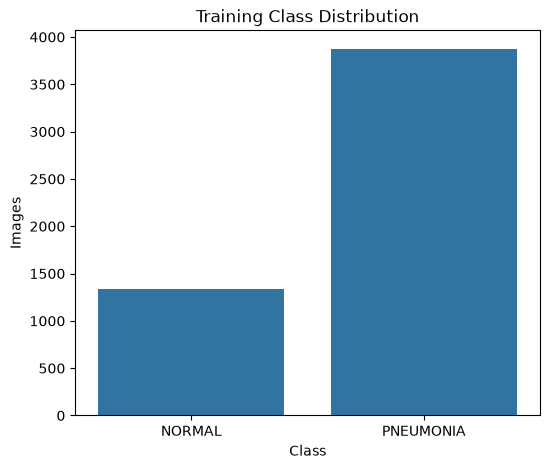

In [32]:
plt.figure(

    figsize=(6,5)

)

sns.barplot(

    x=list(train_counts.keys()),

    y=list(train_counts.values())

)

plt.title(

    "Training Class Distribution"

)

plt.xlabel(

    "Class"

)

plt.ylabel(

    "Images"

)

plt.show()


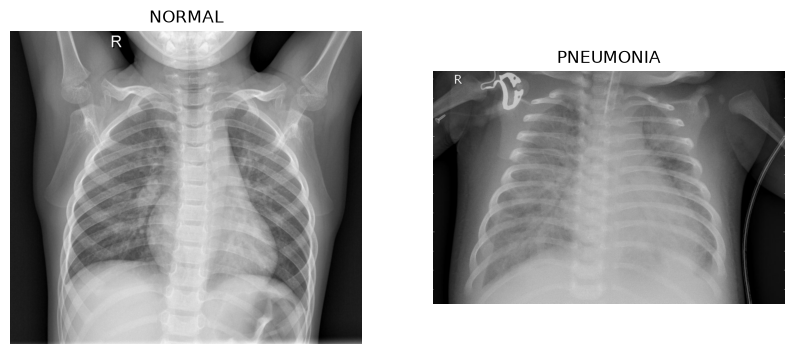

In [33]:
plt.figure(

    figsize=(10,5)

)

for i, category in enumerate(classes):

    image_name = os.listdir(

        os.path.join(

            train_path,

            category

        )

    )[0]

    image_path = os.path.join(

        train_path,

        category,

        image_name

    )

    image = cv2.imread(

        image_path

    )

    image = cv2.cvtColor(

        image,

        cv2.COLOR_BGR2RGB

    )

    plt.subplot(

        1,

        2,

        i+1

    )

    plt.imshow(

        image

    )

    plt.title(

        category

    )

    plt.axis("off")

plt.show()


In [34]:
heights = []

widths = []

for category in classes:

    folder = os.path.join(

        train_path,

        category

    )

    for img_name in os.listdir(folder)[:100]:

        img = cv2.imread(

            os.path.join(

                folder,

                img_name

            )

        )

        if img is not None:

            h, w, _ = img.shape

            heights.append(h)

            widths.append(w)

print("\n")

print("="*70)

print("Image Resolution Statistics")

print("="*70)

print(

    "Average Height :", round(

        np.mean(heights),

        2

    )

)

print(

    "Average Width :", round(

        np.mean(widths),

        2

    )

)

print(

    "Minimum Height :", min(

        heights

    )

)

print(

    "Maximum Height :", max(

        heights

    )

)

print(

    "Minimum Width :", min(

        widths

    )

)

print(

    "Maximum Width :", max(

        widths

    )

)




Image Resolution Statistics
Average Height : 1105.25
Average Width : 1456.8
Minimum Height : 307
Maximum Height : 2025
Minimum Width : 502
Maximum Width : 2396


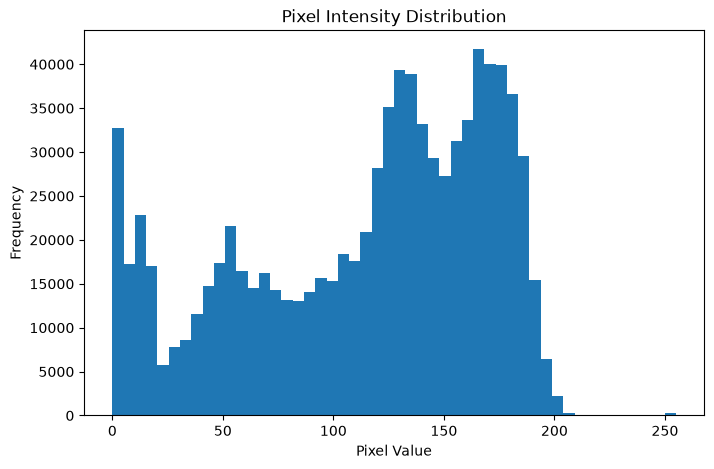

In [35]:
sample_image = cv2.imread(

    image_path,

    cv2.IMREAD_GRAYSCALE

)

plt.figure(

    figsize=(8,5)

)

plt.hist(

    sample_image.ravel(),

    bins=50

)

plt.title(

    "Pixel Intensity Distribution"

)

plt.xlabel(

    "Pixel Value"

)

plt.ylabel(

    "Frequency"

)

plt.show()


In [36]:
print("\n")

print("="*70)

print("Sample Image Shape")

print("="*70)

print(sample_image.shape)



Sample Image Shape
(760, 1152)


In [37]:
summary = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Classes",

        "Training Images",

        "Testing Folder",

        "Validation Folder"

    ],

    "Value":[

        "Chest X-Ray",

        len(classes),

        train_total,

        test_path,

        val_path

    ]

})

print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

display(summary)





Dataset Summary


,Parameter,Value
0,Dataset,Chest X-Ray
1,Classes,2
2,Training Images,5216
3,Testing Folder,archive (22)\chest_xray\test
4,Validation Folder,archive (22)\chest_xray\val


In [38]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n")

print("="*70)

print("TensorFlow Version")

print("="*70)

print(tf.__version__)



TensorFlow Version
2.21.0


In [39]:
IMAGE_HEIGHT = 128

IMAGE_WIDTH = 128

BATCH_SIZE = 16

print("\n")

print("="*70)

print("Image Configuration")

print("="*70)

print("Image Size :", IMAGE_HEIGHT, "x", IMAGE_WIDTH)

print("Batch Size :", BATCH_SIZE)



Image Configuration
Image Size : 128 x 128
Batch Size : 16


In [40]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=10,

    zoom_range=0.10,

    width_shift_range=0.10,

    height_shift_range=0.10,

    horizontal_flip=True

)

In [41]:
validation_datagen = ImageDataGenerator(

    rescale=1./255

)

In [42]:
test_datagen = ImageDataGenerator(

    rescale=1./255

)

In [43]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=True

)


Found 5216 images belonging to 2 classes.


In [44]:
validation_generator = validation_datagen.flow_from_directory(

    val_path,

    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False

)


Found 16 images belonging to 2 classes.


In [45]:
test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False

)

print("\n")

print("="*70)

print("Image Generators Created Successfully")

print("="*70)

Found 624 images belonging to 2 classes.


Image Generators Created Successfully


In [46]:
print("\n")

print("="*70)

print("Class Indices")

print("="*70)

print(

    train_generator.class_indices

)



Class Indices
{'NORMAL': 0, 'PNEUMONIA': 1}


In [47]:
print("\n")

print("="*70)

print("Dataset Statistics")

print("="*70)

print(

    "Training Images :",

    train_generator.samples

)

print(

    "Validation Images :",

    validation_generator.samples

)

print(

    "Testing Images :",

    test_generator.samples

)




Dataset Statistics
Training Images : 5216
Validation Images : 16
Testing Images : 624


In [48]:
images, labels = next(

    train_generator

)

print("\n")

print("="*70)

print("Batch Information")

print("="*70)

print(

    "Image Batch Shape :",

    images.shape

)

print(

    "Label Shape :",

    labels.shape

)




Batch Information
Image Batch Shape : (16, 128, 128, 3)
Label Shape : (16,)


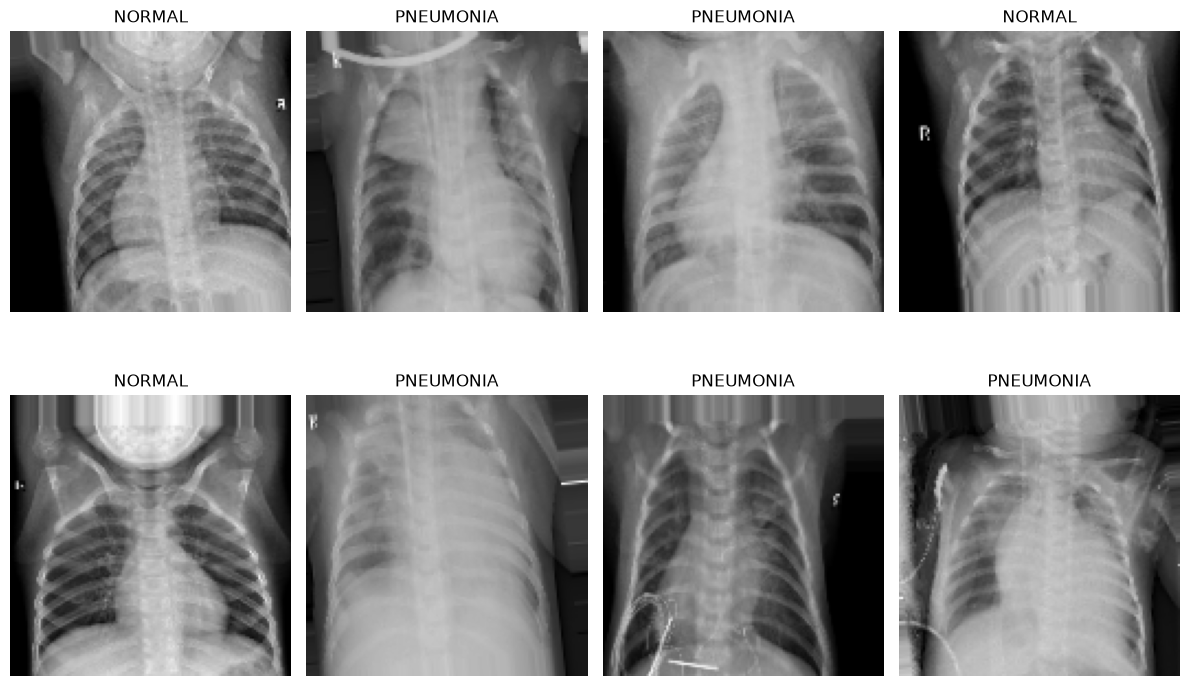

In [49]:
plt.figure(

    figsize=(12,8)

)

for i in range(8):

    plt.subplot(

        2,

        4,

        i+1

    )

    plt.imshow(

        images[i]

    )

    plt.title(

        "NORMAL"

        if labels[i] == 0

        else

        "PNEUMONIA"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()


In [50]:
print("\n")

print("="*70)

print("Pixel Value Verification")

print("="*70)

print(

    "Minimum Pixel :",

    np.min(images)

)

print(

    "Maximum Pixel :",

    np.max(images)

)




Pixel Value Verification
Minimum Pixel : 0.0
Maximum Pixel : 0.9994502


In [51]:
dataset_information = pd.DataFrame({

    "Parameter":[

        "Training Images",

        "Validation Images",

        "Testing Images",

        "Image Size",

        "Batch Size",

        "Classes"

    ],

    "Value":[

        train_generator.samples,

        validation_generator.samples,

        test_generator.samples,

        "128 x 128",

        BATCH_SIZE,

        train_generator.num_classes

    ]

})

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(

    dataset_information

)




Dataset Information


,Parameter,Value
0,Training Images,5216
1,Validation Images,16
2,Testing Images,624
3,Image Size,128 x 128
4,Batch Size,16
5,Classes,2


In [52]:
train_steps = train_generator.samples // BATCH_SIZE

validation_steps = validation_generator.samples // BATCH_SIZE

test_steps = test_generator.samples // BATCH_SIZE

print("\n")

print("="*70)

print("Training Configuration")

print("="*70)

print(

    "Train Steps :", train_steps

)

print(

    "Validation Steps :",

    validation_steps

)

print(

    "Test Steps :",

    test_steps

)




Training Configuration
Train Steps : 326
Validation Steps : 1
Test Steps : 39


In [53]:
print("\n")

print("="*70)

print("Dataset Ready for ResNet50")

print("="*70)





Dataset Ready for ResNet50


In [54]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

import seaborn as sns

import matplotlib.pyplot as plt

import numpy as np


In [55]:
base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(128,128,3)

)

print("\n")

print("="*70)

print("Pretrained ResNet50 Loaded Successfully")

print("="*70)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


Pretrained ResNet50 Loaded Successfully


In [56]:
for layer in base_model.layers:

    layer.trainable = False

print("\n")

print("="*70)

print("Base Model Frozen")

print("="*70)




Base Model Frozen


In [57]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(

    128,

    activation="relu"

)(x)

x = Dropout(

    0.30

)(x)

output = Dense(

    1,

    activation="sigmoid"

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

print("\n")

print("="*70)

print("Custom Classification Head Added")

print("="*70)




Custom Classification Head Added


In [58]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 134, 134, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 32, 32, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [59]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

print("\n")

print("="*70)

print("Model Compiled Successfully")

print("="*70)



Model Compiled Successfully


In [60]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "best_resnet50_model.keras",

    monitor="val_accuracy",

    save_best_only=True

)

In [61]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=5,

    callbacks=[

        early_stop,

        checkpoint

    ],

    verbose=1   

)

print("\n")

print("="*70)

print("Model Training Completed")

print("="*70)


Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.7433 - loss: 0.5420 - val_accuracy: 0.5000 - val_loss: 0.7259
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 1013s 3s/step - accuracy: 0.7659 - loss: 0.4730 - val_accuracy: 0.6250 - val_loss: 0.6052
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 1050s 3s/step - accuracy: 0.7903 - loss: 0.4262 - val_accuracy: 0.5625 - val_loss: 0.7732
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 194s 594ms/step - accuracy: 0.8006 - loss: 0.4037 - val_accuracy: 0.6250 - val_loss: 0.6846


Model Training Completed


In [62]:
loss, accuracy = model.evaluate(

    test_generator,

    verbose=0

)

print("\n")

print("="*70)

print("Test Accuracy")

print("="*70)

print(

    round(

        accuracy,

        4

    )

)




Test Accuracy
0.7997


In [63]:
prediction_probability = model.predict(

    test_generator,

    verbose=0

)

predictions = (

    prediction_probability > 0.5

).astype(int)

true_labels = test_generator.classes

In [64]:
precision = precision_score(

    true_labels,

    predictions

)

recall = recall_score(

    true_labels,

    predictions

)

f1 = f1_score(

    true_labels,

    predictions

)

print("\n")

print("="*70)

print("Evaluation Metrics")

print("="*70)

print(

    "Accuracy :", round(

        accuracy,

        4

    )

)

print(

    "Precision :", round(

        precision,

        4

    )

)

print(

    "Recall :", round(

        recall,

        4

    )

)

print(

    "F1 Score :", round(

        f1,

        4

    )

)




Evaluation Metrics
Accuracy : 0.7997
Precision : 0.8118
Recall : 0.8846
F1 Score : 0.8466


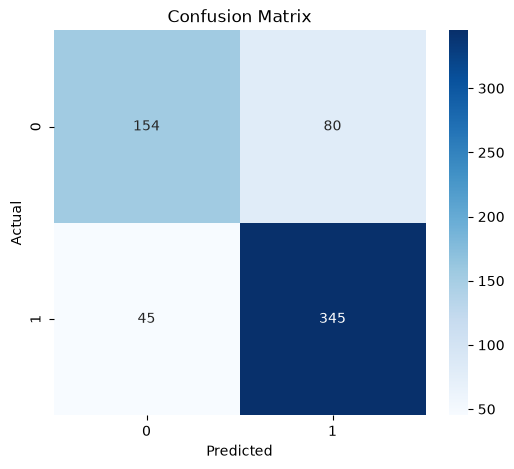

In [65]:
cm = confusion_matrix(

    true_labels,

    predictions

)

plt.figure(

    figsize=(6,5)

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(

    "Confusion Matrix"

)

plt.xlabel(

    "Predicted"

)

plt.ylabel(

    "Actual"

)

plt.show()


In [66]:
print("\n")

print("="*70)

print("Classification Report")

print("="*70)

print(

    classification_report(

        true_labels,

        predictions,

        target_names=[

            "NORMAL",

            "PNEUMONIA"

        ]

    )

)




Classification Report
              precision    recall  f1-score   support

      NORMAL       0.77      0.66      0.71       234
   PNEUMONIA       0.81      0.88      0.85       390

    accuracy                           0.80       624
   macro avg       0.79      0.77      0.78       624
weighted avg       0.80      0.80      0.80       624



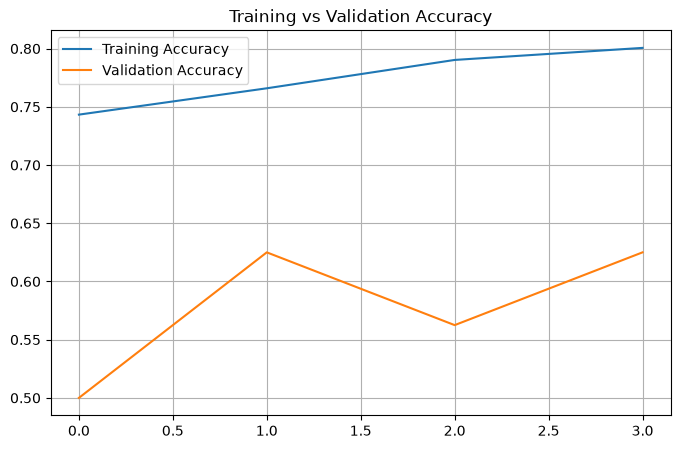

In [67]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.legend()

plt.grid()

plt.title(

    "Training vs Validation Accuracy"

)

plt.show()


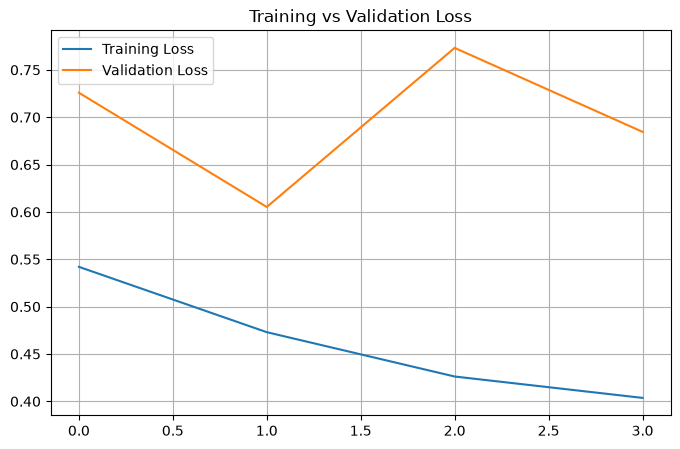

In [68]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.legend()

plt.grid()

plt.title(

    "Training vs Validation Loss"

)

plt.show()


In [69]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- ResNet50 uses residual learning to train deep networks.")

print("- Transfer Learning significantly reduces training time.")

print("- Freezing pretrained layers is ideal for CPU-based training.")

print("- Data augmentation improves model generalization.")

print("- Medical imaging benefits from pretrained ImageNet features.")



Business Insights
- ResNet50 uses residual learning to train deep networks.
- Transfer Learning significantly reduces training time.
- Freezing pretrained layers is ideal for CPU-based training.
- Data augmentation improves model generalization.
- Medical imaging benefits from pretrained ImageNet features.


In [70]:
print("\n")

print("="*70)

print("ResNet50 Model Summary")

print("="*70)

print("Architecture            : ResNet50")

print("Transfer Learning       : Yes")

print("Frozen Layers           : Yes")

print("Epochs                  : 5")

print("Image Size              : 128 x 128")

print("Batch Size              : 16")

print("Optimizer               : Adam")

print("Loss Function           : Binary Crossentropy")

print("Accuracy                :", round(accuracy,4))

print("Precision               :", round(precision,4))

print("Recall                  :", round(recall,4))

print("F1 Score                :", round(f1,4))

print("="*70)







ResNet50 Model Summary
Architecture            : ResNet50
Transfer Learning       : Yes
Frozen Layers           : Yes
Epochs                  : 5
Image Size              : 128 x 128
Batch Size              : 16
Optimizer               : Adam
Loss Function           : Binary Crossentropy
Accuracy                : 0.7997
Precision               : 0.8118
Recall                  : 0.8846
F1 Score                : 0.8466


In [71]:
import tensorflow as tf

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing import image

In [72]:
loaded_model = load_model(

    "best_resnet50_model.keras"

)

print("\n")

print("="*70)

print("ResNet50 Model Loaded Successfully")

print("="*70)



ResNet50 Model Loaded Successfully


In [74]:
image_path = r"archive (22)\chest_xray\test\NORMAL\NORMAL2-IM-0372-0001.jpeg"

img = image.load_img(

    image_path,

    target_size=(128,128)

)

img_array = image.img_to_array(

    img

)

img_array = img_array / 255.0

img_array = np.expand_dims(

    img_array,

    axis=0

)

prediction = loaded_model.predict(

    img_array,

    verbose=0

)

predicted_class = "PNEUMONIA" if prediction[0][0] > 0.5 else "NORMAL"

confidence = prediction[0][0]

print("\n")

print("="*70)

print("Prediction Result")

print("="*70)

print(

    "Predicted Class :",

    predicted_class

)

print(

    "Confidence Score :",

    round(

        float(confidence),

        4

    )

)




Prediction Result
Predicted Class : NORMAL
Confidence Score : 0.3303


In [75]:
prediction_results = []

sample_folder = r"archive (22)\chest_xray\test\NORMAL"

sample_images = os.listdir(

    sample_folder

)[:10]

for file in sample_images:

    path = os.path.join(

        sample_folder,

        file

    )

    img = image.load_img(

        path,

        target_size=(128,128)

    )

    img_array = image.img_to_array(

        img

    )

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0

    )

    pred = loaded_model.predict(

        img_array,

        verbose=0

    )

    label = "PNEUMONIA" if pred[0][0] > 0.5 else "NORMAL"

    prediction_results.append(

        [

            file,

            label,

            float(pred[0][0])

        ]

    )

prediction_df = pd.DataFrame(

    prediction_results,

    columns=[

        "Image",

        "Prediction",

        "Confidence"

    ]

)

print("\n")

print("="*70)

print("Prediction Results")

print("="*70)

display(

    prediction_df

)




Prediction Results


,Image,Prediction,Confidence
0,IM-0001-0001.jpeg,NORMAL,0.374735
1,IM-0003-0001.jpeg,NORMAL,0.399574
2,IM-0005-0001.jpeg,NORMAL,0.410952
3,IM-0006-0001.jpeg,PNEUMONIA,0.676166
4,IM-0007-0001.jpeg,NORMAL,0.355449
5,IM-0009-0001.jpeg,NORMAL,0.461749
6,IM-0010-0001.jpeg,PNEUMONIA,0.571890
7,IM-0011-0001-0001.jpeg,NORMAL,0.490454
8,IM-0011-0001-0002.jpeg,NORMAL,0.479481
9,IM-0011-0001.jpeg,PNEUMONIA,0.538220


In [76]:
prediction_df.to_csv(

    "Medical_Image_Predictions.csv",

    index=False

)

print("\n")

print("="*70)

print("Predictions Exported Successfully")

print("="*70)



Predictions Exported Successfully


In [77]:
evaluation_metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

evaluation_metrics.to_csv(

    "Evaluation_Metrics.csv",

    index=False

)

print("\n")

print("="*70)

print("Evaluation Metrics Saved Successfully")

print("="*70)

display(

    evaluation_metrics

)




Evaluation Metrics Saved Successfully


,Metric,Value
0,Accuracy,0.799679
1,Precision,0.811765
2,Recall,0.884615
3,F1 Score,0.846626


In [78]:
history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("\n")

print("="*70)

print("Training History Saved Successfully")

print("="*70)




Training History Saved Successfully


In [79]:
deployment_summary = pd.DataFrame({

    "File":[

        "ResNet50 Model",

        "Prediction Results",

        "Evaluation Metrics",

        "Training History"

    ],

    "Saved As":[

        "best_resnet50_model.keras",

        "Medical_Image_Predictions.csv",

        "Evaluation_Metrics.csv",

        "Training_History.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment_summary

)




Deployment Summary


,File,Saved As
0,ResNet50 Model,best_resnet50_model.keras
1,Prediction Results,Medical_Image_Predictions.csv
2,Evaluation Metrics,Evaluation_Metrics.csv
3,Training History,Training_History.csv


In [80]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- Transfer Learning dramatically reduces training time.")

print("- Frozen pretrained layers allow efficient CPU training.")

print("- Medical image classification can assist radiologists.")

print("- AI predictions should support, not replace, clinical diagnosis.")

print("- Periodic retraining with updated datasets improves robustness.")




Business Insights
- Transfer Learning dramatically reduces training time.
- Frozen pretrained layers allow efficient CPU training.
- Medical image classification can assist radiologists.
- AI predictions should support, not replace, clinical diagnosis.
- Periodic retraining with updated datasets improves robustness.


In [81]:
print("\n")

print("="*70)

print("Medical Imaging using ResNet50")

print("="*70)

print("Dataset                 : Chest X-Ray Pneumonia")

print("Architecture            : ResNet50")

print("Transfer Learning       : Yes")

print("Problem Type            : Binary Image Classification")

print("Classes                 : NORMAL / PNEUMONIA")

print("Image Size              : 128 x 128")

print("Batch Size              : 16")

print("Epochs                  : 5")

print("Optimizer               : Adam")

print("Loss Function           : Binary Crossentropy")

print("Accuracy                :", round(accuracy,4))

print("Precision               :", round(precision,4))

print("Recall                  :", round(recall,4))

print("F1 Score                :", round(f1,4))

print("Model Saved             : best_resnet50_model.keras")

print("Prediction File         : Medical_Image_Predictions.csv")

print("Metrics File            : Evaluation_Metrics.csv")

print("Training History File   : Training_History.csv")

print("Project Status          : Deployment Ready")

print("="*70)




Medical Imaging using ResNet50
Dataset                 : Chest X-Ray Pneumonia
Architecture            : ResNet50
Transfer Learning       : Yes
Problem Type            : Binary Image Classification
Classes                 : NORMAL / PNEUMONIA
Image Size              : 128 x 128
Batch Size              : 16
Epochs                  : 5
Optimizer               : Adam
Loss Function           : Binary Crossentropy
Accuracy                : 0.7997
Precision               : 0.8118
Recall                  : 0.8846
F1 Score                : 0.8466
Model Saved             : best_resnet50_model.keras
Prediction File         : Medical_Image_Predictions.csv
Metrics File            : Evaluation_Metrics.csv
Training History File   : Training_History.csv
Project Status          : Deployment Ready


In [82]:
print("\n")

print("="*70)

print("Medical Imaging using ResNet50 Completed Successfully!")

print("="*70)



Medical Imaging using ResNet50 Completed Successfully!
